<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg", align="left" width="380" height="120">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.893 - Anàlisi de textos</p>
<p style="margin: 0; text-align:right;">Màster en Ciència de Dades</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicacions</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

# Processament i anàlisi d'informació textual (PRA1)

A la PRA1 treballarem amb un dataset de ressenyes (opinions o reviews) i ho analitzarem seguint un conjunt de tasques: des de la preparació i neteja de les dades, fins a l'avaluació de models de classificació de sentiments. Per tant, els objectius d‟aquesta activitat són:

- Aplicar tècniques de processament de llenguatge natural per a netejar i preprocessar les dades del dataset triat.
- Implementar algorismes d'aprenentatge automàtic, com ara LDA i classificació supervisada, per analitzar els textos de les ressenyes.
- Avaluar el rendiment dels models creats, utilitzant les mètriques adequades

Per tant, en aquesta primera pràctica, revisarem i aplicarem els coneixements apresos als mòduls 2, 3 i 4 de l'assignatura. Concretament tractarem 5 temes.

<ul>
<li>1. Elecció i preparació del dataset (10%).
<li>2. Obtenció de dades (30%).
<li>3. Detecció de temes (30%).
<li>4. Classificació automàtica d'opinions positives i negatives (20%).
<li>5. Avaluació de models de classificació (10%).
</ul>
  
A continuació, es descriu l'estructura de la pràctica a realitzar. Considereu que per a cada apartat, s'han plantejat diversos exercicis a resoldre; i en alguns pocs casos, es proposa la solució per a orientar una mica millor el desenvolupament.

A la següent cel·la es filtren alguns missatges d'avís per a evitar alertes per obsolescència o canvis futurs de llibreries; aquestes línies es poden comentar en cas que es requereixi fer el seguiment d'un problema. A més, s'ha comentat la línia que instal·la `gensim` perquè la seva execució dependrà de si l'entorn de treball té instal·lada per defecte la llibreria. En el cas de Colab, es recomana instal·lar la versió 4.3.3

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

#!pip install gensim     # Instal·lar si necessari.

# 1\. Elecció i preparació del dataset

## 1.1. Descripció i càrrega del dataset

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 1em;">

<strong>Exercici 1.1.1:</strong> En paraules, descriure el títol del dataset seleccionat, l'adreça original (font), i una descripció del mateix.

</div>

#############################################

SOLUCIÓ:
Descripció del dataset

El dataset seleccionat és “Amazon Kindle Book Review for Sentiment Analysis”, disponible públicament a partir de dades d’Amazon recopilades per Julian McAuley (UCSD) i accessibles a: http://jmcauley.ucsd.edu/data/amazon/
.

Aquest conjunt de dades conté ressenyes de llibres de la botiga Kindle d’Amazon, recollides entre maig de 1996 i juliol de 2014. Es tracta d’un subconjunt anomenat 5-core dataset, que inclou únicament usuaris i productes amb almenys 5 ressenyes cadascun. En total, el dataset conté aproximadament 982.619 registres, cosa que el fa prou gran i representatiu per a tasques d’anàlisi de text.

Cada registre inclou diferents camps rellevants com ara: identificador del producte (asin), valoració numèrica (overall), text de la ressenya (reviewText), resum (summary), informació temporal (reviewTime), i dades de l’usuari. La variable overall (valoració) permet derivar la polaritat del sentiment (positiu o negatiu), fet clau per a tasques de classificació supervisada.

Pel que fa a la tipologia de dades, es tracta principalment de text lliure (ressenyes), acompanyat de variables numèriques i categòriques. Això el converteix en un dataset adequat per aplicar tècniques de processament de llenguatge natural (NLP), detecció de temes (com LDA) i classificació de sentiments.

Justificació de l’elecció

Aquest dataset s’ha escollit perquè compleix tots els requisits de la pràctica: conté una gran quantitat de dades textuals reals, permet fer tant anàlisi no supervisada (detecció de temes) com supervisada (classificació de sentiments), i inclou etiquetes implícites (valoracions) per entrenar models. A més, la seva mida i riquesa fan possible obtenir resultats significatius i avaluar correctament el rendiment dels models.

#############################################



**Ejercici 1.1.2**: Càrrega del dataset i descripció de les seves principals característiques: mida, estructura, distribució de classe/ràting, distribució de longituds de text. A més, realitzar l'exploració preliminar del text de les opinions **orientada a descobrir potencials tasques de neteja a realitzar**.



**Important**: En cas d'haver triat un dataset sense una columna que denoti el sentiment de cada text, però sí el rating, en aquest exercici afegir una nova columna de sentiment. Per exemple, si tenim els valors 1 a 5 per a rating, podríem considerar els valors de 1 i 2, com a sentiment negatiu (0), i els valors 4 i 5 com a positiu (1). Per ara, ens centrarem en la classificació binària, per tant, no cal considerar els valors de sentiment “neutral” o rating=3

In [2]:
import pandas as pd

#############################################
# SOLUCIÓ                                   #
#############################################

df = pd.read_csv("all_kindle_review .csv")
df.head()



,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    12000 non-null  int64 
 1   Unnamed: 0      12000 non-null  int64 
 2   asin            12000 non-null  object
 3   helpful         12000 non-null  object
 4   rating          12000 non-null  int64 
 5   reviewText      12000 non-null  object
 6   reviewTime      12000 non-null  object
 7   reviewerID      12000 non-null  object
 8   reviewerName    11962 non-null  object
 9   summary         12000 non-null  object
 10  unixReviewTime  12000 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 1.0+ MB


,Unnamed: 0.1,Unnamed: 0,rating,unixReviewTime
count,12000.00000,12000.000000,12000.000000,1.200000e+04
mean,5999.50000,10024.275667,3.250000,1.344537e+09
std,3464.24595,10502.233123,1.421619,4.369374e+07
min,0.00000,0.000000,1.000000,9.602496e+08
25%,2999.75000,2999.750000,2.000000,1.316218e+09
50%,5999.50000,5999.500000,3.500000,1.356826e+09
75%,8999.25000,12475.750000,4.250000,1.376870e+09
max,11999.00000,47770.000000,5.000000,1.405814e+09


1. Càrrega i inspecció inicial

El dataset es carrega correctament amb 12.000 registres i 11 variables. Les columnes inclouen informació sobre el producte, l’usuari, la valoració i el text de la ressenya.

Observacions importants:

Les columnes Unnamed: 0 i Unnamed: 0.1 són id que no aportan informació.
La majoria de variables són de tipus object (text), excepte rating i unixReviewTime.
Hi ha valors nuls a reviewerName (11962 de 12000), però no afecta directament l’anàlisi de sentiment.

In [4]:
df = df[df['rating'] != 3]

df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

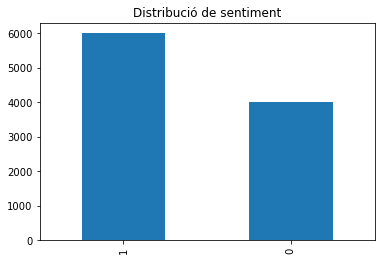

In [5]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Distribució de sentiment")
plt.show()

El gràfic de barres mostra la distribució entre classes positives i negatives.
Tenim més ressenyes positives.
Això pot afectar el model, que podria tendir a predir més la classe majoritària (positives).

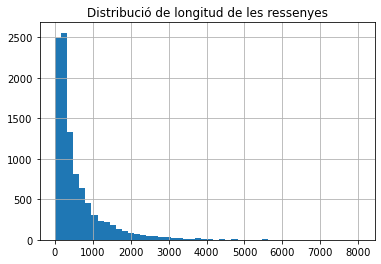

In [6]:
df['review_length'] = df['reviewText'].astype(str).apply(len)
df['review_length'].hist(bins=50)
plt.title("Distribució de longitud de les ressenyes")
plt.show()

Veiem que la majoria de reviews tenen menys de 1000 caracters haurem de mirar si tenim reviews molt curtes que no aporten informació que empitjorant el model, també tenir en compte que potser les reviews molt llarges potser no son representatives ja que son poc habituals

In [7]:
df['reviewText'].sample(5)

3083     Enjoyed this quick adventure. It was a short "...
2962     I liked it better when it was 99cts!!  Now it ...
11244    I enjoyed this story.  I thought there were to...
477      I love the convenience in case I didn't get a ...
2493     Anyone who owns or is friends with a cat will ...
Name: reviewText, dtype: object

Veiem ús de majúscules/minúscules inconsistents
Signes de puntuació
Paraules poc informatives (stopwords)  com the
Possibles errors o variacions lingüístiques com wp per referirese a Washington Post
Totes squestes coses les haurem de tenir en compte quant netegem el text

## 1.2 Neteja de text

Abans de treballar amb els textos de les ressenyes, cal netejar-los. En general, depenent del dataset podria ser necessari:

1. Eliminar mencions (@), hashtags (#), o codi HTML.
2. Eliminar pàgines web.
3. Corregir paraules mal escrites (les que ressaltin al corpus).
4. Contar duplicats i eliminar.
5. Convertir contraccions (per exemple, en lloc de wouldn't, es canviaria a would not).
6. Filtrar tokens no alfabètics.
7. Filtrar signes de puntuació (com ara: ";", ",", "!", "#", etc.) i treure espais dobles. Com a referència vegeu el codi de la PRA proporcionat (document *Exemple_PRA1.ipynb*); el codi elimina tots els signes de puntuació i a la cadena resultant li afegeix el signe ".", ens assegurem així que cada ressenya finalitzi amb aquest símbol; després s'usarà el "." per a crear la llista de sentències.
8. Convertir text a minúscules.
9. Tamany mitjà de frases.

Per cada punt, fer les verificacions necessàries per determinar l'existència de cada element esmentat al punt anterior (mencions, hashtags, codi HTML, pàgines web, etc.) i implementar les accions de neteja (segons es requereixi).

<b>IMPORTANT</b>:
- Abans d'implementar qualsevol acció, se suggereix crear una columna, anomenada *text*, a partir del contingut de la columna de text original del dataset triat; i sobre la nova columna aplicar les tasques de neteja.
- Per cada acció de neteja realitzada, llistar almenys una ressenya que mostri que la funció implementada funciona. És a dir, presentar el text original i el text transformat (*text*).
- Afegir les cel·les de text i codi necessàries, de manera que es realitzin les verificacions suggerides, i es doni solució als problemes de qualitat de dades trobades. Com a orientació, es recomana revisar el fitxer <b>Exemple_PRA1.ipynb</b> per veure la millor manera d'organitzar la solució.

In [8]:
#Crear la columna 'text' per aplicar-hi les tasques de preprocessament i neteja:
df['text'] = df['reviewText'] # Especificar el nom de la columna del dataset triat i el nom del dataframe.

In [9]:
#############################################
#SOLUCIÓ
#############################################
import re
df[df['reviewText'].str.contains(r'<.*?>', regex=True, na=False)].head(1)


,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime,sentiment,review_length,text


In [10]:
df['text'] = df['text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))
row = df[df['reviewText'].str.contains(r'http|www', na=False)].iloc[0]
print("Original:", str(row['reviewText']))
print("Net:", str(row['text']))

Original: More of my reviews can be found on my blog @ http://littlepiecesofimagination.blogspot.com/I jumped into this series without knowing that much about it. People were gushing and raving about this series everywhere and I just couldn't look pass it anymore, so I had to see what it's about.Kaylee is at the mall with her friend Emma and they're trying to figure out a revenge plan on Kaylee's ex as well as shop for homecoming. Then all of a sudden Kaylee feels the urge to scream the heck out of her, because she sees shadows creeping upon a child in a wheelchair and when she starts, she doesn't stop. The next time she's conscious Kaylee realizes she's been commited to a mental hospital. How did it happen and how, when and if she can leave is up for you to find out.The first half of the prequel was intriguing, but I couldn't read more than 5 pages tops every night. My eyelids grew as heavy as rock and I felt like this book didn't attract me at all. I found this whole situation rather

In [11]:
# !pip install contractions
import contractions
df['text'] = df['text'].apply(lambda x: contractions.fix(x))
row = df[df['reviewText'].str.contains(r"n't|'re|'ll|'ve", na=False)].iloc[0]
print("Original:", str(row['reviewText']))
print("Net:", str(row['text']))


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Original: Great short read.  I didn't want to put it down so I read it all in one sitting.  The sex scenes were great between the two males and one female character...a bit surprising - I never thought you could do that!  I learned something new and really enjoyed reading this book!  This is a great way to get all hot and bothered and take advantage of your significant other(s)!
Net: Great short read.  I did not want to put it down so I read it all in one sitting.  The sex scenes were great between the two males and one female character...a bit surprising - I never thought you could do that!  I learned something new and really enjoyed reading this book!  This is a great way to get all hot and bothered and take advantage of your significant other(s)!


In [12]:
num_duplicates = df.duplicated(subset='text').sum()
print("Nombre de duplicats:", num_duplicates)

Nombre de duplicats: 0


In [13]:
pd.set_option('display.max_colwidth', None)
df['reviewText'].sample(5)

8453                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

No s’han detectat errors ortogràfics sistemàtics en el dataset. Tot i que poden existir errors puntuals, aquests no segueixen cap patró clar. Per aquest motiu, no s’ha aplicat cap correcció automàtica, ja que podria introduir soroll i afectar negativament la qualitat del text.

In [14]:
df['text'] = df['text'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', ' ', x)) # En aquest pas fem l'apartat 6 i part del 7 
                                                                       # queda els espais i acabar amb punts
idx = df[df['reviewText'].str.contains(r'\d|\*|\$', regex=True, na=False)].index[0]

print("Original:\n", df.loc[idx, 'reviewText'])
print("\nNet:\n", df.loc[idx, 'text'])

Original:
 I got this because I like collaborated short stories. Alot of times when two good writers put their heads together, the results turn out well. This is the case with this short story. The writers take an age old lesson and turn it into a good read. It begins with, as they call it, Crazy #1 who is picking up a hitchhiker and from there it gets graphic and a little much for my taste. Then it cuts to Nutcase #2 who is hitchhiking. They inevitably get together and the results are suspenseful. The ending I felt was well deserved on both accounts.I also watched the video of the two authors on how they decided to break this short story up and the idea was cool. One wrote their side for scenario 1 and the other did scenario 2 without talking with each other about how tier side was going. Then, when it came for them to bring the two pieces together, they made them fit perfectly. I think it took great talent for two authors to take their two seperate stories and merge them as well as t

In [15]:
df['text'] = df['text'].apply(lambda x: re.sub(r'\s+', ' ', x))     # elimina espais dobles
df['text'] = df['text'].apply(lambda x: x.strip() + '.')            # afegeix punt final
idx = df[df['reviewText'].str.contains(r'\s+', regex=True, na=False)].index[0]

print("Original:\n", df.loc[idx, 'reviewText'])
print("\nNet:\n", df.loc[idx, 'text'])


Original:
 Great short read.  I didn't want to put it down so I read it all in one sitting.  The sex scenes were great between the two males and one female character...a bit surprising - I never thought you could do that!  I learned something new and really enjoyed reading this book!  This is a great way to get all hot and bothered and take advantage of your significant other(s)!

Net:
 Great short read I did not want to put it down so I read it all in one sitting The sex scenes were great between the two males and one female character a bit surprising I never thought you could do that I learned something new and really enjoyed reading this book This is a great way to get all hot and bothered and take advantage of your significant other s.


In [16]:
df['text'] = df['text'].apply(lambda x: x.lower())            # afegeix punt final
idx = df[df['reviewText'].str.contains(r'[A-Z]', regex=True, na=False)].index[0]

print("Original:\n", df.loc[idx, 'reviewText'])
print("\nNet:\n", df.loc[idx, 'text'])

Original:
 Great short read.  I didn't want to put it down so I read it all in one sitting.  The sex scenes were great between the two males and one female character...a bit surprising - I never thought you could do that!  I learned something new and really enjoyed reading this book!  This is a great way to get all hot and bothered and take advantage of your significant other(s)!

Net:
 great short read i did not want to put it down so i read it all in one sitting the sex scenes were great between the two males and one female character a bit surprising i never thought you could do that i learned something new and really enjoyed reading this book this is a great way to get all hot and bothered and take advantage of your significant other s.


Un cop aplicades totes les transformacions, podem tornar a analitzar la longitud de les ressenyes. Observem que la distribució continua sent similar, però amb una concentració lleugerament superior en els valors més petits. Això és coherent amb el procés de neteja: tot i que en alguns casos s’han afegit caràcters, com en l’expansió de contraccions, en general s’han eliminat elements com pàgines web, caràcters no alfabètics, signes de puntuació innecessaris i espais duplicats.

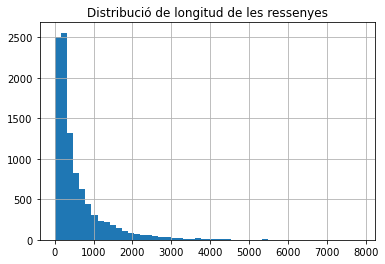

In [17]:
df['review_length'] = df['text'].astype(str).apply(len)
df['review_length'].hist(bins=50)
plt.title("Distribució de longitud de les ressenyes")
plt.show()

# 2\. Obtenció de dades

En aquesta part analitzarem el text, trobarem el conjunt de termes multiparaula rellevants del dataset i analitzarem l'objecte i aspectes de les opinions del text utilitzant el model Word2Wec. Per això començarem calculant els **millors bigrames i trigrames de les opinions del dataset** i els avaluarem segons les mètriques PMI i Likehood.

Posteriorment, detectarem els **n-grames que compleixin un patró sintàctic d'un sintagma nominal** (e.g: adjectiu + nom en singular/plural, nom + nom i nom en singular/plural) i acabarem **detectant col·locacions** amb un model de detecció basat en el mòdul `Phraser` de Gensim.

Un cop analitzats els termes multiparaula, **crearem un model word2vec** amb les opinions lematitzades i l'utilitzarem per analitzar els targets de les opinions.

In [18]:
# Utilitzar el 'magic command' %%capture per a evitar visualitzar els missatges informatius
# de la instal·lació i descàrrega dels fitxers nltk
# (un cop es vegi que la descàrrega es realitza correctament les primeres vegades)
# %%capture

# Per a aquest apartat cal carregar les llibreries següents:
import nltk
# nltk.download('all')
# nltk.download('stopwords')
from nltk import pos_tag, word_tokenize
from nltk.collocations import *

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\alber\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\alber\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\alber\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\alber\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\alber\AppData\Roaming\nltk_data...
[

In [19]:
#Importar la llista de stopwords de l'idioma dels *reviews* de la llibreria NLTK i afegir-ne algunes d'addicionals:
stopwords =  ["would"]
stopwords = stopwords + nltk.corpus.stopwords.words('english')
stopwords[:15] # extracte de stopwords.

['would',
 'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren']

### 2.1. Detecció de col·locacions

Les col·locacions són termes multiparaula, és a dir, seqüències de paraules que, en conjunt, tenen un significat que difereix significativament del significat de cada paraula individual (e.g. "free version" o "new york").

**Exercici 2.1.1:** Calcular els millors bigrames i trigrames de les opinions. Dels millors bigrames i trigrames, escull els que no comencen, ni acaben amb una stopword.

**Sortida esperada:** Imprimir els primers 20 n-grams obtinguts amb cada mètrica.

**Passos a realitzar**:

- Obtenir els tokens del text de les opinions i etiquetar-los pel seu PoS
- Aplicar les mètriques PMI i Likehood Ratio per a calcular els millors bigrames i els millors trigrames a partir dels tokens etiquetats que no comencen ni acaben amb una stopword.

<div style="background-color: #F8F7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    
<i>Primer pas</i>: Obtenir els tokens del text de les ressenyes. Etiqueta aquests tokens pel seu PoS.

Utilitza els mètodes *word_tokenize* per tokenitzar el text de les ressenyes i *pos_tag* per determinar l'etiqueta de cada token.
<br>
<b>Sortida esperada:</b> Imprimeix els deu primers tokens, amb la seva respectiva etiqueta:
</div>

Abans de categoritzar els tokens pel seu tag POS, primer convertirem el text a minúscules:

In [20]:
#Creem text en minúscula que reculli totes les ressenyes.
#A les següents línies df és el dataframe on es va carregar el dataset, i text és la columna que té el text preprocessat.
#Se suggereix actualitzar la línia següent amb els objectes propis i executar les instruccions.
opinions = " ".join(df['text']).lower()
opinions[:250]

'great short read i did not want to put it down so i read it all in one sitting the sex scenes were great between the two males and one female character a bit surprising i never thought you could do that i learned something new and really enjoyed read'

In [21]:
#############################################
# SOLUCIÓ PAS 1                           #
#############################################
from nltk.tokenize import word_tokenize

tokens = word_tokenize(opinions)

from nltk import pos_tag

tagged_tokens = pos_tag(tokens)

print(tagged_tokens[:10])

[('great', 'JJ'), ('short', 'JJ'), ('read', 'NN'), ('i', 'NN'), ('did', 'VBD'), ('not', 'RB'), ('want', 'VB'), ('to', 'TO'), ('put', 'VB'), ('it', 'PRP')]


<div style="background-color: #F8F7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
    
<i>Segon pas</i>: Calcular els 300 millors bigrames i els 300 millors trigrames a partir dels tokens etiquetats (e.g. [(we, PRP), ...]) del text. Utilitza les mètriques PMI i Likehood Ratio.
<br>
<b>Condició</b>: De la llista de millors bigrames i trigrames, escull els que no comencen ni acabin amb una stopword o bé amb termes que no aportin significat. Per al filtratge de stopwords considera:
- La llista de stopwords prèviament carregada (des del paquet NLTK), i
- Les categories POS que representen paraules buides com ara determinants, preposicions, entre d'altres.
<br>
</div>


**Sortida esperada:** Imprimeix els primers 20 n-grams obtinguts amb cada mètrica.

Recordeu la classificació d'etiquetes PoS.

<b>Etiquetes PoS</b>

<ul>
<li>DT: Determinant</li>
<li>JJ: Adjectiu</li>
<li>NN: Nom en singular</li>
<li>NNS: Nom en plural</li>
<li>VBD: Verb en passat</li>
<li>VBG: Verb en gerundi</li>
<li>MD: Verb modal</li>
<li>IN: Preposició o conjunció subordinada</li>
<li>PRP: Pronom</li>
<li>RB: Adverbi</li>
<li>RP: Partícula</li>    
<li>CC: Conjunció coordinada</li>
<li>CD: Numeral</li>
</ul>

In [22]:
#Carreguem les mètriques per al càlcul de bigrames i trigrames:

bigram_measures = nltk.collocations.BigramAssocMeasures()
trigram_measures = nltk.collocations.TrigramAssocMeasures()

##############################################
# SOLUCIÓ PAS 2 #
##############################################
pos_stop = {'DT', 'IN', 'CC', 'PRP', 'PRP$', 'MD', 'TO', 'RP'}
def valid_ngram(ngram):
    words = [w for w, t in ngram]
    tags = [t for w, t in ngram]
    
    # No començar ni acabar amb stopword
    if words[0] in stopwords or words[-1] in stopwords:
        return False
    
    # No començar ni acabar amb PoS poc informatiu
    if tags[0] in pos_stop or tags[-1] in pos_stop:
        return False
    
    return True
ngrams_num = 300

In [23]:
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

# Crear finder amb tokens (només paraules)
words = [w for w, t in tagged_tokens]

bigram_finder = BigramCollocationFinder.from_words(words)

# Top 300 amb PMI
bigrams_pmi = bigram_finder.nbest(bigram_measures.pmi, 300)

# Top 300 amb Likelihood Ratio
bigrams_lr = bigram_finder.nbest(BigramAssocMeasures.likelihood_ratio, 300)

In [24]:
# Crear diccionari paraula → PoS
word_pos = dict(tagged_tokens)

def add_pos(ngrams):
    return [[(w, word_pos.get(w, 'NN')) for w in gram] for gram in ngrams]

bigrams_pmi_tagged = add_pos(bigrams_pmi)
bigrams_lr_tagged = add_pos(bigrams_lr)

# Filtrar
bigrams_pmi_clean = [gram for gram in bigrams_pmi_tagged if valid_ngram(gram)]
bigrams_lr_clean = [gram for gram in bigrams_lr_tagged if valid_ngram(gram)]

In [25]:
print("Top 20 Bigrams PMI:")
for gram in bigrams_pmi_clean[:20]:
    print([w for w, t in gram])

print("\nTop 20 Bigrams Likelihood Ratio:")
for gram in bigrams_lr_clean[:20]:
    print([w for w, t in gram])

Top 20 Bigrams PMI:
['adveinturous', 'romanticnorman']
['aiken', 'sdragon']
['alisha', 'rai']
['amazeen', 'warrioress']
['andtemptation', 'unleashedby']
['angus', 'mckettrich']
['ankh', 'morpork']
['armani', 'apparel']
['artificially', 'inseminated']
['ashkoda', 'paignton']
['auml', 'nger']
['bacs', 'transactions']
['bagpipes', 'haggis']
['baider', 'paider']
['bakerauthor', 'ofstory']
['battleship', 'drones']
['beefy', 'burly']
['behavioral', 'implants']
['beimg', 'umfinished']
['betsey', 'lerner']

Top 20 Bigrams Likelihood Ratio:
['well', 'written']
['short', 'story']
['sex', 'scenes']
['story', 'line']
['sci', 'fi']
['character', 'development']
['main', 'character']
['main', 'characters']
['really', 'enjoyed']
['best', 'friend']
['year', 'old']
['joyfully', 'reviewed']
['looking', 'forward']
['high', 'school']
['look', 'forward']
['highly', 'recommend']
['years', 'ago']
['writing', 'style']
['fast', 'paced']
['science', 'fiction']


In [26]:
df[df['text'].str.contains("bakerauthor", case=False, na=False)]



,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime,sentiment,review_length,text
4557,4557,1089,B0010ZGPB2,"[1, 1]",5,"Author Steve Peek will have me sleeping with the lights on for a while. I thought I was over being afraid of the dark, but not after reading this book... Why do I need the lights on?Answer: Longclaws...Steve Peek's writing style is masterful, unique. Just take a peek between the covers... He has written a story that addresses the human condition, our capacity to deal with the unimaginable, and find a way to carry on. I totally enjoyed everything about this book: the plot, the characters, the style, the pace, its unpredictability, and above all, even my coming nightmares when I turn out the lights! I highly recommend this book.Reviewed by Thomas Jerome BakerAuthor ofStory Tellers: In Pursuit of Happiness","11 8, 2013",A3TE5OTAQOXS65,"Thomas Baker ""Thomas is the Past-President of...",Are You Afraid of the Dark? Yes? then...Don't read this book!,1383868800,1,688,author steve peek will have me sleeping with the lights on for a while i thought i was over being afraid of the dark but not after reading this book why do i need the lights on answer longclaws steve peek s writing style is masterful unique just take a peek between the covers he has written a story that addresses the human condition our capacity to deal with the unimaginable and find a way to carry on i totally enjoyed everything about this book the plot the characters the style the pace its unpredictability and above all even my coming nightmares when i turn out the lights i highly recommend this book reviewed by thomas jerome bakerauthor ofstory tellers in pursuit of happiness.


In [27]:
from nltk.collocations import TrigramCollocationFinder
from nltk.metrics import TrigramAssocMeasures

trigram_finder = TrigramCollocationFinder.from_words(words)

trigrams_pmi = trigram_finder.nbest(TrigramAssocMeasures.pmi, 300)
trigrams_lr = trigram_finder.nbest(TrigramAssocMeasures.likelihood_ratio, 300)

# Afegir PoS
trigrams_pmi_tagged = add_pos(trigrams_pmi)
trigrams_lr_tagged = add_pos(trigrams_lr)

# Filtrar
trigrams_pmi_clean = [gram for gram in trigrams_pmi_tagged if valid_ngram(gram)]
trigrams_lr_clean = [gram for gram in trigrams_lr_tagged if valid_ngram(gram)]

In [28]:
print("\nTop 20 Trigrams PMI:")
for gram in trigrams_pmi_clean[:20]:
    print([w for w, t in gram])

print("\nTop 20 Trigrams Likelihood Ratio:")
for gram in trigrams_lr_clean[:20]:
    print([w for w, t in gram])


Top 20 Trigrams PMI:
['bakerauthor', 'ofstory', 'tellers']
['casi', 'tanto', 'como']
['charlatans', 'quacks', 'frauds']
['chitta', 'vritti', 'narodaham']
['crackernutsthe', 'cauld', 'lad']
['doppelg', 'auml', 'nger']
['est', 'ce', 'pas']
['fantasycover', 'yummmending', 'heai']
['fortunemr', 'vinegarnix', 'nought']
['foxlazy', 'jackjohnny', 'cakeearl']
['fromforsaken', 'talismanby', 'ashleigh']
['fromimmortal', 'illusionsby', 'ursula']
['garnder', 'gerritssen', 'gagnon']
['glinting', 'pennons', 'perspiration']
['hickok', 'plummer', 'slade']
['illusionsby', 'ursula', 'bauer']
['jaye', 'anddunmore', 'risingby']
['jerome', 'bakerauthor', 'ofstory']
['kha', 'gai', 'thai']
['killerhenny', 'pennychilde', 'rowlandmolly']

Top 20 Trigrams Likelihood Ratio:
['.', 'this', 'book']
['recommend', 'this', 'book']
['enjoyed', 'this', 'book']
['reading', 'this', 'book']
['read', 'this', 'book']
['loved', 'this', 'book']
['enjoy', 'this', 'book']
['finish', 'this', 'book']
['bought', 'this', 'book']
['

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 2.1.2:</strong> Detectar n-grames que compleixen el patró sintàctic d'un sintagma nominal (e.g: adjectiu + nom en singular/plural, nom + nom i nom en singular/plural). Les paraules components de cada n-grama han d'estar separades per un guió baix "_".
<br>
<b>Sortida esperada:</b> Llista dels 20 primers n-grames que compleixin el patró sintàctic especificat, per exemple, 'new_york' i 'tourism'.

</div>

In [29]:
#############################################
# SOLUCIÓ                                  #
#############################################
from nltk.util import bigrams

bigram_tagged = list(bigrams(tagged_tokens))
noun_phrases = []

for ((w1, t1), (w2, t2)) in bigram_tagged:
    
    # Patrons:
    if (t1 == 'JJ' and t2 in ['NN', 'NNS']) or \
       (t1 in ['NN', 'NNS'] and t2 in ['NN', 'NNS']):
        
        noun_phrases.append(f"{w1}_{w2}")
noun_phrases = list(set(noun_phrases))
print("Top 20 sintagmes nominals:")
print(noun_phrases[:20])

Top 20 sintagmes nominals:
['glossy_cover', 'language_i', 'mate_leyland', 'try_glad', 'original_philosophy', 'main_killer', 'lithe_imagination', 'cover_problem', 'irritating_read', 'sorrow_hope', 'prison_office', 'typical_dickens', 'old_daughter', 'helpless_falls', 'specs_books', 'weird_i', 'way_thoughts', 'inner_history', 'books_jacob', 'little_fluff']


**Exercici 2.1.3:** Detectar col·locacions amb el mòdul Phraser de Gensim. Entrenar el model amb totes les opinions.

**Passos a realitzar**:

1. Crear la llista de `sentences`. Prendre com a referència el codi comentat que consta a la cel·la següent.
2. Entrenar el model de detecció de col·locacions usant `Phraser` de Gensim i convertir les ressenyes en una llista de `phrases` segons Gensim.

**Desenvolupament**:

*Primer pas*: Crear la llista de `sentences`.

In [30]:
#Crear la llista de ‘sentences’. Les línies següents es poden prendre com a referència.
#Actualitzar el nom del dataframe i de la columna del text pre-processat.#
opinions_string = " ".join(df['text'])

opinion_sentences = opinions_string.split('. ')

opinion_sentences[:10]


['great short read i did not want to put it down so i read it all in one sitting the sex scenes were great between the two males and one female character a bit surprising i never thought you could do that i learned something new and really enjoyed reading this book this is a great way to get all hot and bothered and take advantage of your significant other s',
 'i did not expect this type of book to be in library was pleased to find it price was right',
 'aislinn is a little girl with big dreams after the death of her older brother she decides to follow in his footsteps and become a lady knight her quest for knighthood brings many challenges and the temptation of forbidden love aislinn learns that being a knight means putting the kingdom in front of personal concerns and helping those that cannot help themselves in a journey is fraught with danger and filled with adventure aislinn is forced to grow up fast she must stay strong and develop the skills necessary to realize her lifelong dr

*Segon pas*: Entrenar el model de detecció de col·locacions usant `Phraser` de Gensim i convertir les ressenyes en una llista de *phrases* denominada `opinion_phrases_no_stopwords`.

Condicions:
* Les paraules de cada expressió multiparaula han d'estar separades amb un guió baix (_).
* Les `phrases` no han de ser stopwords; ni han de començar ni acabar amb stopwords. Utilitza la llista de stopwords per al filtratge.

**Sortida esperada**:

Llista de les 20 primeres `phrases` que no siguin, o no continguin stopwords.


In [31]:
from gensim.models.phrases import Phraser
from gensim.models import Phrases

#############################################
# SOLUCIÓ PAS 2                           #
#############################################
from nltk.tokenize import word_tokenize

sentences_tokens = [word_tokenize(sentence) for sentence in opinion_sentences]
phrases = Phrases(sentences_tokens, min_count=5, threshold=10)

phraser = Phraser(phrases)

In [32]:
sentences_phrased = [phraser[sentence] for sentence in sentences_tokens]

In [33]:
def valid_phrase(word):
    if '_' not in word:
        return False
    
    parts = word.split('_')
    
    # no començar ni acabar amb stopword
    if parts[0] in stopwords or parts[-1] in stopwords:
        return False
    
    return True

In [34]:
opinion_phrases_no_stopwords = []

for sentence in sentences_phrased:
    for word in sentence:
        if valid_phrase(word):
            opinion_phrases_no_stopwords.append(word)

In [35]:
opinion_phrases_no_stopwords = list(set(opinion_phrases_no_stopwords))

In [36]:
print("Top 20 phrases:")
print(opinion_phrases_no_stopwords[:20])

Top 20 phrases:
['gargoyle_spin', 'poor_writing', 'long_ago', 'hot_sex', 'norse_mythology', 'makes_sense', 'one_star', 'required_reading', 'quit_reading', 'beautifully_written', 'fast_pace', 'many_levels', 'take_place', 'every_minute', 'dionne_courtesy', 'unexpected_twists', 'cliffhanger_ending', 'years_earlier', 'home_planet', 'things_happen']


## 2.2 Vectorització de paraules i termes amb Word2Vec

Abans de desenvolupar els exercicis, cal importar gensim i treure espais del text.

In [37]:
# Importar el paquet gensim, que implementa un mètode per entrenar models Word2Vec.

import gensim

#Abans de continuar se suggereix treure espais del text: considerar el codi comentat següent.
#Considereu que, opinion_phrases_no_stopwords és l'objecte generat en el segon pas de l'Exercici 2.1.3.

opinion_phrases_stripped_no_stopwords = [c.strip() for c in opinion_phrases_no_stopwords]
opinion_phrases_stripped_no_stopwords[:10]

['gargoyle_spin',
 'poor_writing',
 'long_ago',
 'hot_sex',
 'norse_mythology',
 'makes_sense',
 'one_star',
 'required_reading',
 'quit_reading',
 'beautifully_written']

**Exercici 2.2.1:** Obtenir targets de les opinions i els seus aspectes utilitzant el model Word2vec.

**Sortida esperada:** Llista dels primers 15 termes que tinguin més relació semàntica amb el terme/aspecte seleccionat.
<br><br>
Passos a realitzar:
1. Convertir les `phrases` de cada oració en un token.
2. Crear una *sentence stream* on tots els tokens de les oracions estiguin lematitzats. Els tokens no poden ser stopwords ni tenir un stopword al començament o al final.
3. Crear un model *word2vec* de les opinions lematitzades. Anomeneu el model *w2v_opinions*.
4. A partir del vocabulari del model *word2vec*, seleccionar possibles aspectes representatius de les opinions.

**Primer pas**: Convertir les `phrases` de cada oració en un token. Per completar aquest pas:


- A cada oració substituir els bigrames que són `phrases` per la forma tokenitzada (e.g: "This is one of the best apps apps according to a bunch of people and..." -> "This is one of the best_apps apps according to a bunch of people and...".
- En fer els passos anteriors, les col·locacions formaran part del vocabulari del model *word2vec* que generarem.

*Important:* El codi següent es pot prendre com a referència per completar aquest primer pas. Considereu que:

- *opinion_phrases_stripped_no_stopwords* és l'objecte creat en iniciar aquest apartat (2.2).
- *opinion_sentences* és la llista de *sentences* creada al primer pas de l'Exercici 2.1.3.

In [44]:
from nltk.util import ngrams
def transform_sentence(sentence):
    
    tokens = nltk.word_tokenize(sentence)
    transformed_sentence = sentence
    
    # generar bigrames
    n_grams = list(ngrams(tokens, 2))
    
    for gram in n_grams:
        bigram = "_".join(gram).lower()
        
        if bigram in opinion_phrases_no_stopwords:
            original = " ".join(gram)
            transformed_sentence = transformed_sentence.replace(original, bigram)
    
    return transformed_sentence

In [45]:
opinion_sentences_transformed = [
    transform_sentence(s) for s in opinion_sentences
]

In [46]:
print(opinion_sentences[0])
print(opinion_sentences_transformed[0])

great short read i did not want to put it down so i read it all in one sitting the sex scenes were great between the two males and one female character a bit surprising i never thought you could do that i learned something new and really enjoyed reading this book this is a great way to get all hot and bothered and take advantage of your significant other s
great short read i did not want to put it down so i read it all in one_sitting the sex_scenes were great between the two males and one female_character a bit surprising i never thought you could do that i learned something new and really_enjoyed_reading this book this is a great way to get all hot and bothered and take_advantage of your significant other s


**Segon pas**: Crear una *sentence stream* on tots els tokens de les oracions estiguin lematitzats. Els tokens no poden ser stopwords ni tenir un stopword al començament o al final. Per simplificar la tasca, podem considerar que el lema d'una col·locació no canvia i el seu PoS és 'col'. (e.g: ['We run a top of the line system utilizing Windows 10 Pro'] -> [run', 'top', 'line', 'system', 'utilize', 'windows_pro']).
<br><br>
**Sortida esperada:** Llista dels 10 primers tokens lematitzats (que no siguin, ni continguin stopwords).

In [47]:
##############################################
# SOLUCIÓ #
##############################################

#Importar els mètodes de la llibreria NLTK que lematitzen segons Wordnet
from nltk.stem.wordnet import WordNetLemmatizer

#Per a obtenir el lema, el terme ha de tenir una etiqueta PoS. El format de l'etiqueta PoS de Wordnet és
#diferent de l'etiqueta del pos tagger de NLTK

lemmatizer = WordNetLemmatizer()
def process_sentence(sentence):
    tokens = word_tokenize(sentence.lower())
    clean_tokens = []
    for word in tokens:
        # Si és col·locació → mantenir tal qual
        if '_' in word:
                clean_tokens.append(word)
        else:
            # eliminar stopwords
            if word in stopwords:
                continue
            lemma = lemmatizer.lemmatize(word)
            clean_tokens.append(lemma)
    
    return clean_tokens

In [48]:
sentences_lemmas = [process_sentence(s) for s in opinion_sentences_transformed]
print(sentences_lemmas[0])

['great', 'short', 'read', 'want', 'put', 'read', 'one_sitting', 'sex_scenes', 'great', 'two', 'male', 'one', 'female_character', 'bit', 'surprising', 'never', 'thought', 'could', 'learned', 'something', 'new', 'really_enjoyed_reading', 'book', 'great', 'way', 'get', 'hot', 'bothered', 'take_advantage', 'significant']


**Tercer pas**: Crear un model *word2vec* de les opinions lematitzades. El model s'ha de dir w2v_opinions.
<br><br>
**Sortida esperada:** Mostrar la quantitat d'oracions usades al model (usa l'atribut `corpus_count`).

In [49]:
#############################################
# SOLUCIÓ                                   #
#############################################
from gensim.models import Word2Vec

w2v_opinions = Word2Vec(
    sentences=sentences_lemmas,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)


In [50]:
print("Nombre d'oracions:", w2v_opinions.corpus_count)

Nombre d'oracions: 10000


**Quart pas**: A partir del vocabulari del model word2vec, seleccionar possibles aspectes de la ressenya (e.g: en un dataset sobre aplicacions de software, es podria destacar l'aspecte *desktop*) i llista els termes semànticament relacionats amb aquests aspectes segons aquest model.
<br><br>

**Sortida esperada:** Llista els primers 20 termes que tinguin més relació semàntica amb un terme rellevant del domini.

In [51]:
##############################################
# SOLUCIÓ                                    #
##############################################

# Obtenir el vocabulari del model d'opinions:
vocab = list(w2v_opinions.wv.index_to_key)
print(vocab[:20])

['book', 'story', 'read', 'one', 'character', 'like', 'good', 'love', 'author', 'get', 'really', 'time', 'could', 'series', 'first', 'much', 'know', 'reading', 'great', 'way']


In [52]:
w2v_opinions.wv.most_similar("book", topn=20)


[('reading', 0.8928036689758301),
 ('read', 0.8878639936447144),
 ('anyone', 0.8847669959068298),
 ('author', 0.8809380531311035),
 ('chapter', 0.877341091632843),
 ('definitely', 0.8767077922821045),
 ('disappointed', 0.8755619525909424),
 ('others', 0.8750958442687988),
 ('looking_forward', 0.8727867603302002),
 ('star', 0.8727304935455322),
 ('collection', 0.8694780468940735),
 ('bundle', 0.866900622844696),
 ('probably', 0.8668254613876343),
 ('writer', 0.8623509407043457),
 ('rest', 0.8585267066955566),
 ('look_forward', 0.8557583689689636),
 ('thesis', 0.8554213047027588),
 ('bought', 0.8552724123001099),
 ('one_sitting', 0.8543108105659485),
 ('buy', 0.8540488481521606)]

# 3\. Detecció de temes

En aquesta part explorarem els temes detectats utilitzant *WordNet* i farem l'extracció de temes a partir de LDA.

## 3.1 Exploració dels temes amb WordNet

Per a accedir a *Wordnet*, utilitzeu la llibreria `nltk`.

In [53]:
from nltk.corpus import wordnet as wn

**Exercici 3.1.1:** Comprovar si, segons *Wordnet*, hi ha aspectes que estan allunyats semànticament del sentit del target, encara que en el model *word2vec* siguin similars.

Calcular la similitud de *Wu and Palmer* entre el sentit de *wordnet* del terme elegit (i.e 'word.n.01') i alguns dels seus aspectes.
<br><br>
**Sortida esperada:**

- Llista de dos termes que segons *Wordnet* no estiguin tan propers, i el seu respectiu resultat de similitud, i
- Llista dels mateixos termes que segons el model *word2vec* estan més propers.

In [54]:
#############################################
# SOLUCIÓ                                   #
#############################################
target = "book"
similar_words = w2v_opinions.wv.most_similar(target, topn=10)

print(similar_words)

[('reading', 0.8928036689758301), ('read', 0.8878639936447144), ('anyone', 0.8847669959068298), ('author', 0.8809380531311035), ('chapter', 0.877341091632843), ('definitely', 0.8767077922821045), ('disappointed', 0.8755619525909424), ('others', 0.8750958442687988), ('looking_forward', 0.8727867603302002), ('star', 0.8727304935455322)]


In [55]:
from nltk.corpus import wordnet as wn

book = wn.synset('book.n.01')
author = wn.synset('author.n.01')
reading = wn.synset('reading.n.01')

print(book.wup_similarity(author))
print(book.wup_similarity(reading))

0.42105263157894735
0.1111111111111111


**Exercici 3.1.2:** Identificar els termes monoparaula del vocabulari de *word2vec* que no són a *Wordnet*. Filtrar els termes que siguin noms o adjectius.

Del conjunt de termes identificats, cal esmentar:
- Abreviatures o termes específics del domini o expressions típiques de l'argot. Per exemple, en un dataset sobre restaurants, podrien identificar-se termes com ara *yummy*.
<br><br>
**Sortida esperada:**
- Quantitat de termes que no consten a *Wordnet*.
- Llista els 20 primers termes monoparaula que no consten a *Wordnet*.
- Llista almenys 3 termes dels llistats que, siguin inherents al vocabulari propi del domini

In [56]:
#############################################
# SOLUCIÓ                                   #
#############################################
vocab = list(w2v_opinions.wv.index_to_key)
single_words = [w for w in vocab if '_' not in w]
from nltk.corpus import wordnet as wn

not_in_wordnet = [
    word for word in single_words
    if len(wn.synsets(word)) == 0
]

In [57]:
print(not_in_wordnet[:20])

['could', 'something', 'since', 'without', 'anything', 'everything', 'others', 'anyone', 'although', 'everyone', 'alex', 'etc', 'kate', 'upon', 'bdsm', 'unless', 'jake', 'whether', 'prequel', 'emma']


In [58]:
print(not_in_wordnet[18])
print(not_in_wordnet[20])
print(not_in_wordnet[89])

prequel
ebook
mitch


## 3.2. LDA

Aquest apartat té com a objectiu comparar diferents models LDA i triar el més adequat de manera justificada.

**Passos a seguir:**

1. Convertir les opinions transformades en llistes de noms i col·locacions.
2. Extreure temes a partir de les llistes de noms i col·locacions de cada oració transformada. Triar 3 dels millors experiments, segons el paràmetre `num_topics`, i presentar-ne els resultats. Assignar noms als temes trobats.
3. Utilitzar la llibreria pyLDAvis per a visualitzar els tòpics del millor model que s'ha identificat.

**Primer pas**: Convertir les opinions transformades (opinion_sentences_transformed) en llistes de noms i col·locacions. Això és necessari ja que els noms i les col·locacions expressen els temes de les opinions (e.g: [['This is a one of the best_apps according to the people opinions') -> ['one', 'best_apps', 'according' , 'people', 'opinion'].
<br><br>
**Important:** El codi següent es pot prendre com a referència per implementar aquest primer pas:

- opinion_sentences_transformed és l'objecte creat al primer pas de l'Exercici 2.2.1.

In [61]:
lem = WordNetLemmatizer()

def get_noun_and_collocation(sentence):
   nouns_and_collocations = []
   noun_tags = ['NN', 'NNS']
   tokens_pos_tagged = pos_tag(word_tokenize(sentence))
   for tpos in tokens_pos_tagged:
       lemma = lem.lemmatize(tpos[0]).lower()
       if '_' in lemma:
           nouns_and_collocations.append(lemma)
       elif tpos[1] in noun_tags and tpos[0] not in stopwords:
           nouns_and_collocations.append(lemma)
   return nouns_and_collocations

noun_and_collocation_stream = [get_noun_and_collocation(opinion) for opinion in opinion_sentences_transformed]

noun_and_collocation_stream[:15]


[['read',
  'one_sitting',
  'sex_scenes',
  'male',
  'female_character',
  'bit',
  'something',
  'really_enjoyed_reading',
  'book',
  'way',
  'take_advantage'],
 ['type', 'book', 'library', 'price'],
 ['aislinn',
  'little_girl',
  'dream',
  'death',
  'older_brother',
  'footstep',
  'lady_knight',
  'knighthood',
  'brings',
  'challenge',
  'temptation',
  'love',
  'aislinn',
  'knight',
  'kingdom',
  'front',
  'concern',
  'journey',
  'danger',
  'adventure',
  'aislinn',
  'skill',
  'dream',
  'fight',
  'creature',
  'game',
  'woman',
  'honor',
  'kind',
  'book',
  'idea',
  'history',
  'fantasy',
  'zoltack',
  'book',
  'real_life',
  'story',
  'group',
  'knight',
  'history',
  'fiction',
  'writing',
  'plot',
  'adventure',
  'character',
  'hardship',
  'success',
  'protagonist',
  'beautiful',
  'romance',
  'prince',
  'well_developed',
  'year',
  'friendship',
  'enjoyed_reading',
  'courtship',
  'idea',
  'romance',
  'm',
  'zoltack',
  'twist',
  

**Exercici 3.2.1:** Extreure temes a partir de les llistes de noms i col·locacions de cada oració transformada. A més, utilitza la llibreria *pyLDAvis* per visualitzar els tòpics del millor model que has trobat. Fes servir la funció de CoherenceModel i la mètrica c_v per determinar quin número de tòpics es el més rellevant.

**Sortida esperada:**
- De cadascun dels 3 millors experiments, imprimeix les 10 paraules que més es destaquin de cada tòpic i la mètrica c_v. Justificar quins sons els millors experiments i perquè.
- Visualitza el millor experiment, usant *pyLDAvis*.

In [62]:
from gensim import corpora

dictionary = corpora.Dictionary(noun_and_collocation_stream)

corpus = [dictionary.doc2bow(text) for text in noun_and_collocation_stream]
from gensim.models import LdaModel
from gensim.models import CoherenceModel

results = []

In [98]:
#Experiment 1: amb n1 tòpics:

##############################################
# SOLUCIÓ #
##############################################
lda_model_5 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10
)

coherence_model = CoherenceModel(
    model=lda_model,
    texts=noun_and_collocation_stream,
    dictionary=dictionary,
    coherence='c_v'
)

coherence = coherence_model.get_coherence()

results.append((5, lda_model, coherence))

print(f"\nModel amb {5} tòpics - Coherence: {coherence:.4f}")

for idx, topic in lda_model_5.print_topics(num_words=10):
    print(f"Tòpic {idx}: {topic}")



Model amb 5 tòpics - Coherence: 0.5064
Tòpic 0: 0.011*"family" + 0.010*"series" + 0.010*"brother" + 0.009*"love" + 0.009*"life" + 0.008*"man" + 0.008*"story" + 0.007*"mate" + 0.007*"time" + 0.006*"wife"
Tòpic 1: 0.018*"kindle" + 0.008*"time" + 0.007*"price" + 0.006*"case" + 0.006*"thing" + 0.006*"day" + 0.006*"content" + 0.006*"story" + 0.005*"amazon" + 0.005*"cover"
Tòpic 2: 0.022*"story" + 0.015*"life" + 0.013*"woman" + 0.011*"man" + 0.010*"love" + 0.009*"men" + 0.006*"relationship" + 0.006*"friend" + 0.005*"home" + 0.005*"time"
Tòpic 3: 0.010*"mystery" + 0.008*"h" + 0.006*"reader" + 0.006*"novel" + 0.006*"story" + 0.006*"time" + 0.005*"tale" + 0.005*"world" + 0.005*"way" + 0.004*"adventure"
Tòpic 4: 0.101*"book" + 0.053*"story" + 0.028*"character" + 0.022*"author" + 0.015*"series" + 0.014*"time" + 0.010*"way" + 0.010*"plot" + 0.009*"read" + 0.008*"thing"


In [99]:
#Experiment 2: amb n2 tòpics:

##############################################
# SOLUCIÓ                                    #
##############################################
lda_model_7 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=7,
    random_state=42,
    passes=10
)

coherence_model = CoherenceModel(
    model=lda_model,
    texts=noun_and_collocation_stream,
    dictionary=dictionary,
    coherence='c_v'
)

coherence = coherence_model.get_coherence()

results.append((7, lda_model, coherence))

print(f"\nModel amb {7} tòpics - Coherence: {coherence:.4f}")

for idx, topic in lda_model_7.print_topics(num_words=10):
    print(f"Tòpic {idx}: {topic}")



Model amb 7 tòpics - Coherence: 0.5064
Tòpic 0: 0.008*"family" + 0.008*"wife" + 0.008*"man" + 0.007*"brother" + 0.007*"life" + 0.007*"world" + 0.006*"alex" + 0.005*"death" + 0.005*"husband" + 0.005*"time"
Tòpic 1: 0.009*"zombie" + 0.007*"jane" + 0.007*"justin" + 0.006*"story" + 0.005*"recipe" + 0.005*"serial_killer" + 0.005*"cover" + 0.005*"car" + 0.005*"beast" + 0.005*"jon"
Tòpic 2: 0.028*"story" + 0.013*"tale" + 0.010*"life" + 0.007*"fairy_tale" + 0.007*"men" + 0.006*"man" + 0.006*"child" + 0.005*"word" + 0.005*"robyn" + 0.005*"world"
Tòpic 3: 0.027*"kindle" + 0.013*"h" + 0.009*"time" + 0.008*"magazine" + 0.007*"mystery" + 0.007*"paper" + 0.007*"content" + 0.007*"case" + 0.007*"amazon" + 0.006*"blog"
Tòpic 4: 0.113*"book" + 0.053*"story" + 0.030*"character" + 0.023*"author" + 0.018*"series" + 0.015*"time" + 0.011*"way" + 0.011*"plot" + 0.009*"read" + 0.009*"thing"
Tòpic 5: 0.033*"story" + 0.020*"book" + 0.011*"time" + 0.009*"author" + 0.008*"novel" + 0.008*"family" + 0.008*"characte

In [72]:
#Experiment 3: amb n3 tòpics:

##############################################
# SOLUCIÓ                                    #
##############################################
lda_model_10 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10
)

coherence_model = CoherenceModel(
    model=lda_model,
    texts=noun_and_collocation_stream,
    dictionary=dictionary,
    coherence='c_v'
)

coherence = coherence_model.get_coherence()

results.append((10, lda_model, coherence))

print(f"\nModel amb {10} tòpics - Coherence: {coherence:.4f}")

for idx, topic in lda_model_10.print_topics(num_words=10):
    print(f"Tòpic {idx}: {topic}")



Model amb 10 tòpics - Coherence: 0.5064
Tòpic 0: 0.012*"holiday" + 0.012*"alex" + 0.011*"brother" + 0.010*"family" + 0.009*"charlie" + 0.008*"j" + 0.008*"slave" + 0.007*"husband" + 0.007*"wade" + 0.007*"wife"
Tòpic 1: 0.013*"jane" + 0.012*"master" + 0.012*"justin" + 0.010*"bdsm" + 0.009*"beast" + 0.008*"christmas" + 0.008*"beauty" + 0.008*"hunter" + 0.007*"sex" + 0.007*"advice"
Tòpic 2: 0.015*"angel" + 0.011*"kid" + 0.009*"cup" + 0.008*"tea" + 0.008*"tale" + 0.008*"ghost" + 0.007*"wizard" + 0.007*"fog" + 0.007*"max" + 0.006*"adult"
Tòpic 3: 0.033*"kindle" + 0.032*"h" + 0.023*"cover" + 0.019*"case" + 0.018*"fairy_tale" + 0.012*"parker" + 0.009*"amazon" + 0.008*"finish_reading" + 0.007*"product" + 0.007*"paul"
Tòpic 4: 0.041*"book" + 0.026*"story" + 0.016*"time" + 0.015*"character" + 0.014*"woman" + 0.013*"thing" + 0.013*"life" + 0.011*"sex" + 0.011*"way" + 0.010*"people"
Tòpic 5: 0.023*"story" + 0.015*"time" + 0.012*"book" + 0.010*"kindle" + 0.007*"reader" + 0.007*"work" + 0.006*"way" 

In [66]:
best_model = max(results, key=lambda x: x[2])

print("\nMillor model:", best_model[0], "tòpics")
print("Coherence:", best_model[2])


Millor model: 5 tòpics
Coherence: 0.5144777275167558


Fes servir la llibreria pyLDAvis per visualitzar els tòpics del millor model trobat.

In [67]:
!pip install pyLDAvis

#Instal·lar la versió pandes 1.5.3 si utilitzeu Google Colab com a entorn d'execució.
#!pip install pandes==1.5.3


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [68]:


#########################################
# SOLUCIÓ: Visualitzar el millor model
#########################################
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

vis = gensimvis.prepare(best_model[1], corpus, dictionary)
# Hem donava probblemas per poder mostrar-ho en la presetacio, per tant l'he generat apart
pyLDAvis.save_html(vis, "lda.html")

**Exercici opcional:** Prenent com a base els resultats de cada model LDA, calculeu les mètriques de qualitat anomenades *perplexitat* i *coherència*, les quals estan definides en el paquet gensim.
<br><br>
Tant la perplexitat com la coherència són mètriques complementàries. Una perplexitat baixa indica que el model pot generalitzar bé noves dades, mentre que una alta coherència indica que els temes generats són interpretables i diferents entre si. Quan avaluem el rendiment d‟un model LDA, se suggereix triar models que evidenciïn un equilibri entre ambdues mètriques.
<br><br>
Com indica l'enunciat, aquest exercici és opcional, però ha estat incorporat a la pràctica per si algú vol aprofundir una mica més en el tema. Les mètriques esmentades ens poden ajudar a tenir un criteri addicional per triar el model de temes més adequats. Per a una introducció bàsica d'aquest tema podrien revisar el post següent (https://medium.com/@iqra.bismi/topic-modelling-using-lda-fe81a2a806e0)
<br><br>
**Sortida esperada:**
<br>
- Valors de coherència i perplexitat de cada model (pots fer servir el valor absolut calculat per a una millor interpretació) de cadascun dels 3 models de LDA.

</div>

In [73]:
#############################################
# SOLUCIÓ                                  #
#############################################

from gensim.models import CoherenceModel

models = {
    "LDA_5": lda_model_5,
    "LDA_7": lda_model_7,
    "LDA_10": lda_model_10
}

for name, model in models.items():
    
    # Coherència (c_v)
    coherence_model = CoherenceModel(
        model=model,
        texts=noun_and_collocation_stream,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    coherence = coherence_model.get_coherence()
    
    # Perplexitat
    perplexity = model.log_perplexity(corpus)
    
    print(f"\n {name}")
    print(f"Coherència (c_v): {coherence:.4f}")
    print(f"Perplexitat: {abs(perplexity):.4f}")


 LDA_5
Coherència (c_v): 0.5145
Perplexitat: 7.6650

 LDA_7
Coherència (c_v): 0.4585
Perplexitat: 7.7064

 LDA_10
Coherència (c_v): 0.5064
Perplexitat: 7.9930


In [ ]:
Respecte la coherència (c_v)
El millor model és LDA_5 (0.5145)
Això indica que els temes són més interpretables, més consistents semànticament i estan més ben separats
LDA_7 és el pitjor en coherència.

Respecte la Perplexitat
El millor (més baixa) és LDA_5 (7.6650)
Per tant te millor capacitat de generalització i millor ajust al corpus

LDA_10 és el pitjor (massa complex → pitjor generalització)

# 4\. Classificació automàtica d'opinions positives i negatives

L'objectiu d'aquesta part serà crear un classificador que permeti, donat un text, identificar la seva polaritat. Aquesta quarta part consta de dos exercicis.

## 4.1 Crear un classificador binari

**Passos a seguir:**

1. Crear dues llistes, una amb els textos preprocessats (columna `text`) i una altra amb les etiquetes de valoració (0 i 1).
2. Vectoritzar les opinions amb un vectoritzador `tf.idf`. Feu servir `word` com a `analyzer`.
3. Preparar el corpus d'entrenament i avaluació i entrenar el classificador amb *Logistic Regression*.
4. Utilitzar el model entrenat per predir la categoria 1 (positiu) o 0 (negatiu) de les opinions del conjunt de test i mostrar les paraules més informatives per a cada categoria.

**Desenvolupament**:
<br><br>
*Primer pas*: Crear dues llistes. Una amb els textos preprocessats i una altra amb les etiquetes de valoració (0 i 1).
<br><br>
**Sortida esperada:** Llista de les 3 primeres opinions.

In [74]:
#############################################
# SOLUCIÓ                                   #
#############################################
# Llista de textos preprocessats
X = df['text'].tolist()

# Llista d'etiquetes (0 = negatiu, 1 = positiu)
y = df['sentiment'].tolist()

# Mostrar les 3 primeres opinions
print(X[:3])

['great short read i did not want to put it down so i read it all in one sitting the sex scenes were great between the two males and one female character a bit surprising i never thought you could do that i learned something new and really enjoyed reading this book this is a great way to get all hot and bothered and take advantage of your significant other s.', 'i did not expect this type of book to be in library was pleased to find it price was right.', 'aislinn is a little girl with big dreams after the death of her older brother she decides to follow in his footsteps and become a lady knight her quest for knighthood brings many challenges and the temptation of forbidden love aislinn learns that being a knight means putting the kingdom in front of personal concerns and helping those that cannot help themselves in a journey is fraught with danger and filled with adventure aislinn is forced to grow up fast she must stay strong and develop the skills necessary to realize her lifelong dr

*Segon pas*: Vectoritzar les opinions amb un vectoritzador `tf.idf`. Usar `word` com a `analyzer`.
<br><br>

**Sortida esperada:** Imprimir la matriu dels vectors corresponents a les primeres 5 opinions.


In [75]:
#############################################
# SOLUCIÓ                                   #
#############################################
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear vectoritzador TF-IDF amb word analyzer
vectorizer = TfidfVectorizer(analyzer='word')

# Ajustar i transformar les dades
X_tfidf = vectorizer.fit_transform(X)

# Mostrar les primeres 5 opinions en format vector
print(X_tfidf[:5].toarray())


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


*Tercer pas*: Preparar el corpus d'entrenament i avaluació, i entrenar el classificador amb Logistic Regression.
<br><br>
**Sortida esperada:** Temps d'execució que comporta fer l'entrenament (fit()).

In [76]:
#############################################
# SOLUCIÓ                                   #
#############################################
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import time

# Dividir dataset en train i test
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# Crear model
model = LogisticRegression(max_iter=1000)

# Mesurar temps d'entrenament
start_time = time.time()

model.fit(X_train, y_train)

end_time = time.time()

print("Temps d'entrenament (fit):", end_time - start_time, "segons")

Temps d'entrenament (fit): 0.22733664512634277 segons


*Quart pas*: Utilitzar el model entrenat per a predir la categoria 1 (positiu) o 0 (negatiu) de les opinions del conjunt de test i mostrar les paraules més informatives per a cada categoria.
<br><br>
**Sortida esperada:** Llista de les 10 paraules més informatives de cada categoria.

In [80]:
#############################################
# SOLUCIÓ                                   #
#############################################
import numpy as np

# Prediccions
y_pred = model.predict(X_test)

# Obtenir paraules del vocabulari
feature_names = vectorizer.get_feature_names_out()

# Coeficients del model
coefficients = model.coef_[0]

# Top paraules positives (classe 1)
top_pos_idx = np.argsort(coefficients)[-10:]
top_neg_idx = np.argsort(coefficients)[:10]

print("\n Paraules més informatives POSITIU (1):")
print([feature_names[i] for i in reversed(top_pos_idx)])

print("\n Paraules més informatives NEGATIU (0):")
print([feature_names[i] for i in top_neg_idx])


 Paraules més informatives POSITIU (1):
['enjoyed', 'loved', 'great', 'liked', 'good', 'well', 'read', 'hot', 'fun', 'love']

 Paraules més informatives NEGATIU (0):
['not', 'no', 'boring', 'just', 'waste', 'then', 'sorry', 'nothing', 'money', 'sex']


In [81]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.879


##4.2: Identificar sobre quins aspectes es fan valoracions negatives.

**Passos a seguir:**

1. Triar dues paraules més informatives de la categoria 0 i un conjunt d'opinions en què apareguin aquestes paraules. Preprocessar les opinions traient els caràcters de salt de línia.
2. Utilitzar el diccionari d'opinions (arxiu AFINN-111) per a extreure la polaritat de cada opinió com a mitjana dels valors de les 'opinion words' del text.
3. Seleccionar opinions amb polaritat negativa que exemplifiquin els aspectes més mal valorats. En el document d'anàlisi comenta quins són aquests aspectes.

*Primer pas*: Triar les dues paraules més informatives de la categoria 0 i un conjunt d'opinions en què apareguin aquestes paraules. Preprocessar les opinions traient els caràcters de salt de línia.
<br><br>
**Sortida esperada:** Llista de les 3 primeres opinions en què apareguin els termes seleccionats.

In [86]:
#############################################
# SOLUCIÓ                                   #
#############################################

# He escollit aquests termes perque hem semblaven més rellevants que termes com not o no que tot i ser negatius depenen
# del context per exemple i do not undestand how this book is so good es una review positiva pero te not
negative_terms = ['boring', 'waste']

print("Paraules més representatives del sentiment negatiu:")
print(negative_terms)



Paraules més representatives del sentiment negatiu:
['boring', 'waste']


In [87]:
# Funció per netejar salts de línia
def clean_text(text):
    return str(text).replace("\n", " ").strip()

# Aplicar neteja
df['text_clean'] = df['text'].apply(clean_text)

# Filtrar opinions que continguin alguna de les paraules negatives
mask = df['text_clean'].str.contains('|'.join(negative_terms), case=False, na=False)

negative_opinions = df[mask]['text_clean']

# Mostrar exemples
print("Exemples d'opinions negatives:")
print(negative_opinions.head(5).tolist())

Exemples d'opinions negatives:
['i cannot believe this was listed as a romance i read romance novels because i am looking for something uplifting this book was dark depressing i did not find the story or the writing to be bad just depressing sex was very high overview and it did not go into any depth on the developement of the characters relationship spoiler alert if you like a happy ending forget this it was said in other reviews but i guess not strongly enough for me to truly understand hopefully i can say this plainly enough that others with the same expectations as me do not waste their time the hero dies a brutal death saving the heroine the book continues for several chapters showing how the remaining characters pick up their lives go on it ends with the heroine sitting on a porch contemplating her life wondering what lies ahead for her now that the man she loves is gone i did almost cry at the end but in anger that i had wasted my free time reading this book.', 'this book was a 

*Segon pas*: Utilitzar el diccionari d'opinions (arxiu AFINN-111) per a extreure la polaritat de cada opinió com la mitjana dels valors de les *opinion words* del text.
<br><br>
**Sortida esperada:** Llista de les 3 primeres opinions negatives i la respectiva puntuació de polaritat.

In [88]:
#############################################
# SOLUCIÓ                                   #
#############################################
import pandas as pd

# Carregar fitxer AFINN-111 (ajusta el path si cal)
afinn = pd.read_csv("AFINN-111.txt", sep="\t", header=None)
afinn.columns = ["word", "score"]

# Convertir a diccionari
afinn_dict = dict(zip(afinn['word'], afinn['score']))

print("Exemple AFINN:", list(afinn_dict.items())[:5])


Exemple AFINN: [('abandon', -2), ('abandoned', -2), ('abandons', -2), ('abducted', -2), ('abduction', -2)]


In [89]:
import numpy as np
import re

def sentiment_score(text):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    
    scores = [afinn_dict[w] for w in words if w in afinn_dict]
    
    if len(scores) == 0:
        return 0  # si no hi ha paraules amb sentiment
    
    return np.mean(scores)

In [90]:
# reutilitzem negative_opinions del pas anterior

negative_sample = negative_opinions.head(10)

results = []

for op in negative_sample:
    score = sentiment_score(op)
    results.append((op, score))

# ordenar per més negatives
results_sorted = sorted(results, key=lambda x: x[1])

# mostrar 3 més negatives
print("3 opinions més negatives segons AFINN:\n")

for text, score in results_sorted[:3]:
    print("Opinió:", text)
    print("Polaritat:", score)
    print("-" * 80)

3 opinions més negatives segons AFINN:

Opinió: some bookswhich are advertised as christian fiction are really not this is one of them the characters acted spoiled controlling and in my opinion just pretended to be christians this book was not well written and had many incorrectly used words for example you are instead of your the repetition was very boring.
Polaritat: -3.0
--------------------------------------------------------------------------------
Opinió: i will never understand how a nymphomaniac can be sexually boring but this one is i thought my husband and i would get some ideas we did we got an idea that this book was written by someone that was as sexually experienced as a leper.
Polaritat: -3.0
--------------------------------------------------------------------------------
Opinió: other reviewers were right on the money when they pointed out that this book could have benefited tremendously from quality editing particularly if the editor had the sense to tell the author th

*Tercer pas:* Seleccionar opinions amb polaritat negativa que exemplifiquin els aspectes pitjor valorats (utilitzar un llindar per a seleccionar les pitjors ressenyes). Comenta quins són aquests aspectes.
<br><br>
**Sortida esperada:**
* Llista de les tres primeres opinions negatives.
* Explora els textos per a descobrir els aspectes pitjor valorats pels clients.


In [91]:
#############################################
# SOLUCIÓ                                   #
#############################################

# Calculem polaritat per totes les opinions negatives seleccionades
scored_opinions = []

for op in negative_opinions.head(200):  # podem ampliar mostra
    score = sentiment_score(op)
    scored_opinions.append((op, score))

# Definim un llindar per considerar opinió negativa forta
threshold = -1.0

# Filtrar només opinions realment negatives
filtered_negatives = [x for x in scored_opinions if x[1] <= threshold]

# Ordenar de més negatiu a menys
filtered_negatives = sorted(filtered_negatives, key=lambda x: x[1])

# Mostrar les 3 primeres
print("3 opinions més negatives:\n")

for text, score in filtered_negatives[:3]:
    print("Opinió:", text)
    print("Polaritat:", score)
    print("-" * 80)

3 opinions més negatives:

Opinió: some bookswhich are advertised as christian fiction are really not this is one of them the characters acted spoiled controlling and in my opinion just pretended to be christians this book was not well written and had many incorrectly used words for example you are instead of your the repetition was very boring.
Polaritat: -3.0
--------------------------------------------------------------------------------
Opinió: i will never understand how a nymphomaniac can be sexually boring but this one is i thought my husband and i would get some ideas we did we got an idea that this book was written by someone that was as sexually experienced as a leper.
Polaritat: -3.0
--------------------------------------------------------------------------------
Opinió: i really do not understand how it can be dark enough to keep you from driving home but light enough to let you see all the minor facial expressions scowls hooded eyes etc that clutter this story a boring cou

In [92]:
# Mostrar mostres per detectar temes
for text, score in filtered_negatives[:10]:
    print(text)
    print("-" * 80)

some bookswhich are advertised as christian fiction are really not this is one of them the characters acted spoiled controlling and in my opinion just pretended to be christians this book was not well written and had many incorrectly used words for example you are instead of your the repetition was very boring.
--------------------------------------------------------------------------------
i will never understand how a nymphomaniac can be sexually boring but this one is i thought my husband and i would get some ideas we did we got an idea that this book was written by someone that was as sexually experienced as a leper.
--------------------------------------------------------------------------------
i really do not understand how it can be dark enough to keep you from driving home but light enough to let you see all the minor facial expressions scowls hooded eyes etc that clutter this story a boring couple that is not already together for boring reasons she is too tiny for him gets th

Apartir de les opinions amb polaritat més negativa, s’observen diversos patrons recurrents que permeten identificar els principals aspectes pitjor valorats pels usuaris.

1. Històries avorrides i manca de ritme narratiu
Aquest és l’aspecte que apareix amb més freqüència. En moltes ressenyes es repeteixen termes com boring, slow, drawn out o expressions com nothing happens. Això indica que una part dels lectors percep les obres com a lentes, amb poc dinamisme i amb una capacitat limitada per mantenir l’interès.

2. Personatges poc desenvolupats o poc creïbles
També és recurrent la crítica a la construcció dels personatges. Expressions com flat characters, weak characterization o no depth suggereixen que molts usuaris consideren que els personatges tenen poca profunditat psicològica i resulten poc convincents.

3. Problemes d’escriptura i qualitat lingüística
Un altre bloc de crítiques fa referència a la qualitat formal del text. Apareixen comentaris relacionats amb poor writing, grammatical errors o incorrectly used words, fet que apunta a problemes d’estil, correcció lingüística o revisió editorial.

4. Trames poc interessants o mal desenvolupades
Finalment, diverses opinions negatives assenyalen que la trama és poc sòlida o poc atractiva. Expressions com plot thin, not well written story o disappointing indiquen que algunes ressenyes perceben les històries com a previsibles, superficials o mal executades.

En conjunt, les valoracions negatives no es concentren únicament en un únic aspecte, sinó que combinen problemes de ritme narratiu, construcció de personatges, qualitat de l’escriptura i desenvolupament de la trama. Això reforça la idea que la insatisfacció dels usuaris està relacionada sobretot amb la qualitat literària global de les obres analitzades.

# 5\. Avaluació: comparació de models i discussió de resultats

**Exercici 5.1:** Obtenir els resultats de les mètriques d'avaluació del classificador basat en *regressió logística*.

**Sortida esperada:** Mètriques de rendiment del model de regressió logística (per classe).


In [93]:
##############################################
# SOLUCIÓ MODEL REGRESSIÓ LOGÍSTICA          #
##############################################
from sklearn.metrics import classification_report, confusion_matrix

# Prediccions del model (ja entrenat abans)
y_pred = model.predict(X_test)

# Informe de classificació
report = classification_report(y_test, y_pred)

print("Resultats del classificador (Logistic Regression):\n")
print(report)

Resultats del classificador (Logistic Regression):

              precision    recall  f1-score   support

           0       0.89      0.80      0.84       811
           1       0.87      0.93      0.90      1189

    accuracy                           0.88      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.88      0.88      2000



C:\Users\alber\anaconda3\lib\site-packages\seaborn\rcmod.py:82: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(mpl.__version__) >= "3.0":
C:\Users\alber\anaconda3\lib\site-packages\setuptools\_distutils\version.py:337: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  other = LooseVersion(other)


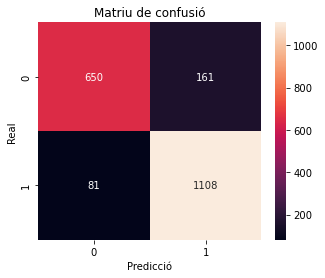

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriu de confusió")
plt.xlabel("Predicció")
plt.ylabel("Real")
plt.show()

**Exercici 5.2:** Obtenir també els resultats de les mètriques d'avaluació per a un classificador diferent. Per exemple, utilitzar *SVM*.
<br><br>
**Sortida esperada:**
<br>
- Temps d'execució de l'entrenament (fit()).
- Mètriques de rediment del model *SVM* (per classe).
<br>
</div>

In [95]:
#############################################
# SOLUCIÓ  MODEL SVM                       #
#############################################
from sklearn.svm import LinearSVC
import time

# Crear model SVM (Lineal és millor per text)
svm_model = LinearSVC()

# Mesurar temps d'entrenament
start = time.time()
svm_model.fit(X_train, y_train)
end = time.time()

print("Temps d'entrenament SVM (segons):", end - start)

Temps d'entrenament SVM (segons): 0.07893848419189453


In [96]:
from sklearn.metrics import classification_report

# Prediccions
y_pred_svm = svm_model.predict(X_test)

# Informe de rendiment
print("Resultats del model SVM:\n")
print(classification_report(y_test, y_pred_svm))

Resultats del model SVM:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       811
           1       0.91      0.93      0.92      1189

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



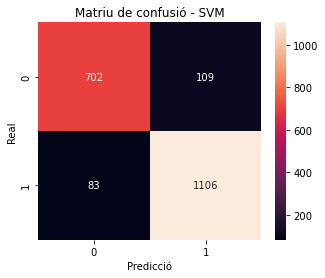

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriu de confusió - SVM")
plt.xlabel("Predicció")
plt.ylabel("Real")
plt.show()